In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
test = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/ML Projects/GiveMeSomeCredit/cs-test.csv")
train = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/ML Projects/GiveMeSomeCredit/cs-training.csv")

In [3]:
test.shape

(101503, 12)

In [4]:
train.shape

(150000, 12)

In [5]:
df = train.copy()

In [6]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [8]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [9]:
df["SeriousDlqin2yrs"].value_counts(normalize= True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

#### Dataset Yorumu
- Veri seti 150k gözlem ve 12 değişkenden oluşuyor. Hedef değişken SeriousDlqin2yrs olup, müşterilerin 2 yıl içerisinde defaulta düşme oranını gösterir. 
- Hedef değişken dağılımında %6.7 oranında pozitif sınıf gözükmektedir. Bu da veri setinin imbalanced olduğunu gösteirr. Bu nedenle model performansını değerlendirirken accuracy değil, ROC-AUC, Recall ve Precision gibi metrikler kullanılacaktır.
- Ayrıca MonthlyIncome ve NumberOfDependents değişkenlerinde eksik değerler gözlemlenmektedir. Bu eksiklerin rastgele olup olmadığı analiz edilecektir.

#### Kolonlar ve İncelemeleri
| Kolon                                    | Teknik Anlamı                                             | Bankacılık Yorumu                                   |
| ---------------------------------------- | --------------------------------------------------------- | --------------------------------------------------- |
| **SeriousDlqin2yrs**                     | Önümüzdeki 2 yıl içinde 90+ gün gecikmeye düştü mü? (0/1) | Hedef değişkenimiz. 1 = problemli müşteri           |
| **RevolvingUtilizationOfUnsecuredLines** | Kullanılan revolving limit / toplam revolving limit       | Kredi kartı limit kullanım oranı gibi düşünülebilir |
| **age**                                  | Müşteri yaşı                                              | Yaş arttıkça risk profili değişebilir               |
| **NumberOfTime30-59DaysPastDueNotWorse** | Son dönemde 30-59 gün arası gecikme sayısı                | En güçlü risk sinyallerinden biridir                |
| **DebtRatio**                            | Toplam borç ödeme yükü / gelir                            | Gelire göre borçluluk seviyesi                      |
| **MonthlyIncome**                        | Aylık gelir                                               | Müşterinin ödeme kapasitesi                         |
| **NumberOfOpenCreditLinesAndLoans**      | Açık kredi ve kredi hesabı sayısı                         | Bankacılık ilişkisi yoğunluğu                       |
| **NumberOfTimes90DaysLate**              | 90+ gün gecikme sayısı                                    | Çok kritik risk göstergesi                          |
| **NumberRealEstateLoansOrLines**         | Konut kredisi veya ipotekli kredi sayısı                  | Gayrimenkul kredi ilişkileri                        |
| **NumberOfTime60-89DaysPastDueNotWorse** | 60-89 gün arası gecikme sayısı                            | Temerrüde yaklaşan davranış                         |
| **NumberOfDependents**                   | Bakmakla yükümlü olunan kişi sayısı                       | Finansal yük göstergesi                             |
| **Unnamed: 0**                           | ID kolonu                                                 | Modele sokulmayacak                                 |


In [10]:
df = df.drop("Unnamed: 0", axis = 1)

In [11]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [12]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [13]:
pd.set_option('display.float_format', '{:.2f}'.format)

#### Eksik Değer Analizi


In [14]:
monthly_missing = df[df["MonthlyIncome"].isnull()]

In [15]:
monthly_not_missing = df[df["MonthlyIncome"].notnull()]

In [16]:
monthly_missing["SeriousDlqin2yrs"].value_counts(normalize= True)

SeriousDlqin2yrs
0   0.94
1   0.06
Name: proportion, dtype: float64

In [17]:
monthly_not_missing["SeriousDlqin2yrs"].value_counts(normalize= True)

SeriousDlqin2yrs
0   0.93
1   0.07
Name: proportion, dtype: float64

In [18]:
df[df["NumberOfDependents"].isnull()]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
8,0,0.12,27,0,46.00,NaN,2,0,0,0,NaN
96,0,0.54,48,2,10.00,NaN,2,0,0,0,NaN
109,0,0.04,61,0,4739.00,NaN,11,0,4,0,NaN
159,0,0.00,63,0,2.00,NaN,4,0,0,0,NaN
238,0,1.00,28,0,0.00,NaN,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
149826,0,0.03,71,0,1419.00,NaN,13,0,1,0,NaN
149854,0,0.06,75,0,8.00,NaN,3,0,0,0,NaN
149894,0,0.02,55,0,1058.00,NaN,8,0,1,1,NaN
149948,0,0.06,27,0,10.00,NaN,1,0,0,0,NaN


In [19]:
depentends_notnull = df[df["NumberOfDependents"].notnull()]

In [20]:
depentends_isnull = df[df["NumberOfDependents"].isnull()]

In [21]:
depentends_isnull["SeriousDlqin2yrs"].value_counts(normalize= True)

SeriousDlqin2yrs
0   0.95
1   0.05
Name: proportion, dtype: float64

In [22]:
depentends_notnull["SeriousDlqin2yrs"].value_counts(normalize= True)

SeriousDlqin2yrs
0   0.93
1   0.07
Name: proportion, dtype: float64

<Axes: xlabel='NumberOfTime30-59DaysPastDueNotWorse'>

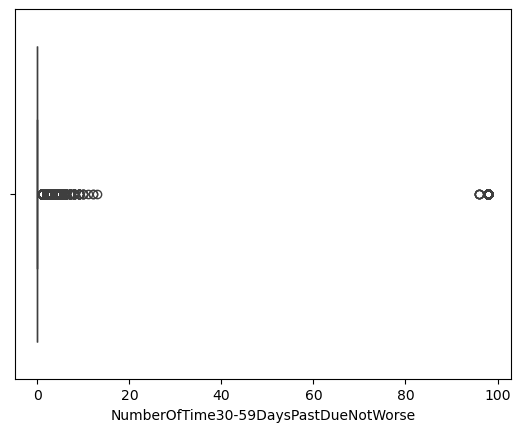

In [23]:
sns.boxplot(x = df["NumberOfTime30-59DaysPastDueNotWorse"])

In [24]:
df["NumberOfTime30-59DaysPastDueNotWorse"].value_counts().sort_index()

NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

In [25]:
df[df["NumberOfTime30-59DaysPastDueNotWorse"] == 98]["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
1    143
0    121
Name: count, dtype: int64

In [26]:
df[df["NumberOfTimes90DaysLate"] == 98]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1733,1,1.00,27,98,0.00,2700.00,0,98,0,98,0.00
2286,0,1.00,22,98,0.00,NaN,0,98,0,98,0.00
3884,0,1.00,38,98,12.00,NaN,0,98,0,98,0.00
4417,0,1.00,21,98,0.00,0.00,0,98,0,98,0.00
4705,0,1.00,21,98,0.00,2000.00,0,98,0,98,0.00
...,...,...,...,...,...,...,...,...,...,...,...
147774,1,1.00,68,98,255.00,NaN,0,98,0,98,0.00
149153,1,1.00,24,98,54.00,NaN,0,98,0,98,0.00
149239,0,1.00,26,98,0.00,2000.00,0,98,0,98,0.00
149439,1,1.00,34,98,9.00,NaN,0,98,0,98,0.00


In [27]:
df.shape

(150000, 11)

In [28]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [29]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
1,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
2,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
3,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
4,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [31]:
box_columns = ["NumberOfTime30-59DaysPastDueNotWorse", "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans", "NumberOfTimes90DaysLate",
               "NumberRealEstateLoansOrLines", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfDependents"]

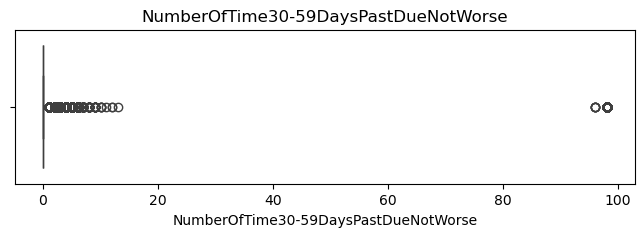

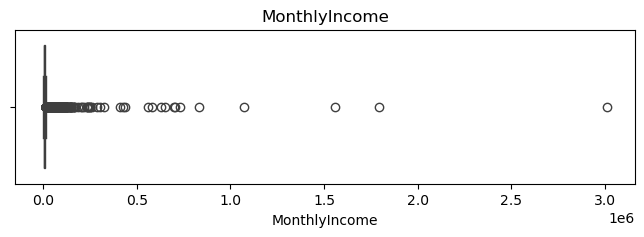

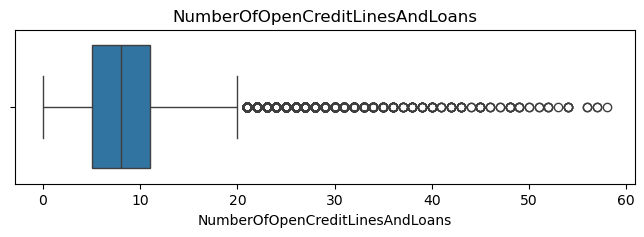

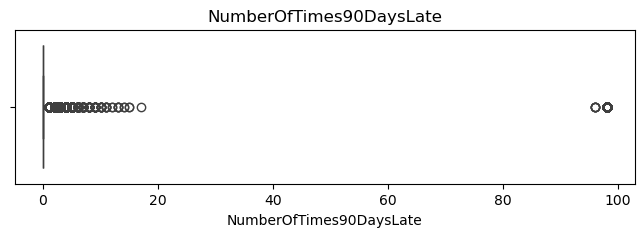

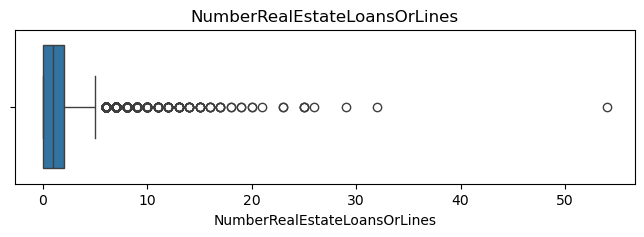

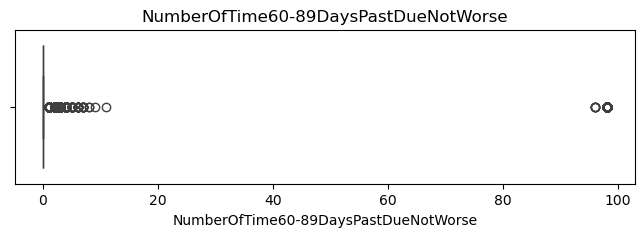

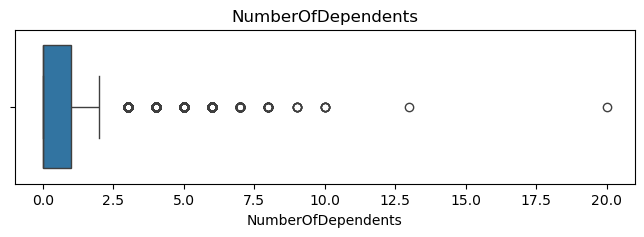

In [32]:
for col in box_columns:
    plt.figure(figsize=(8,2))
    sns.boxplot(data = df, x = col)
    plt.title(col)
    plt.show()

In [33]:
hist_columns = ["NumberOfTime30-59DaysPastDueNotWorse", "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans", 
                "NumberOfTimes90DaysLate",
               "NumberRealEstateLoansOrLines", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfDependents",
               "DebtRatio", "RevolvingUtilizationOfUnsecuredLines"]

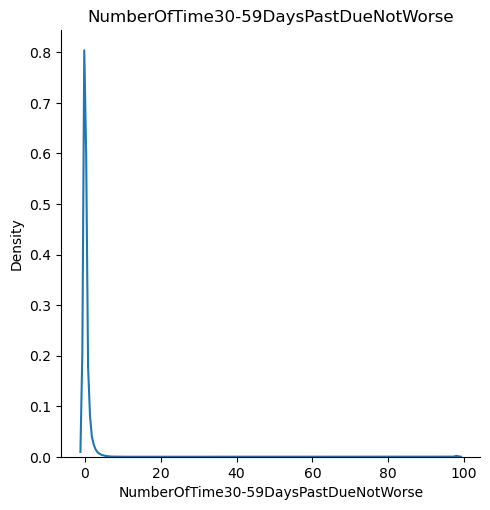

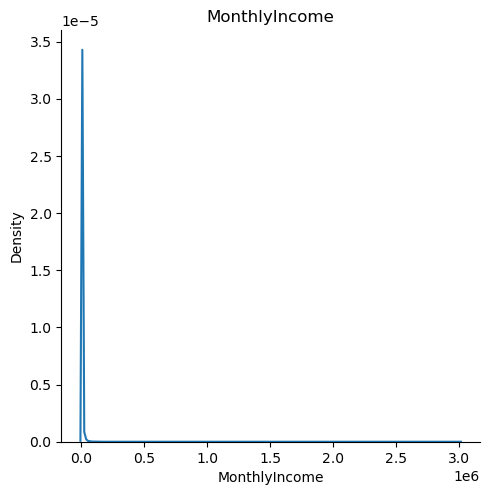

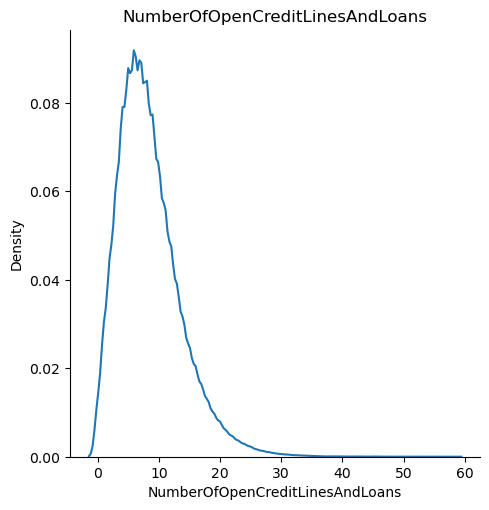

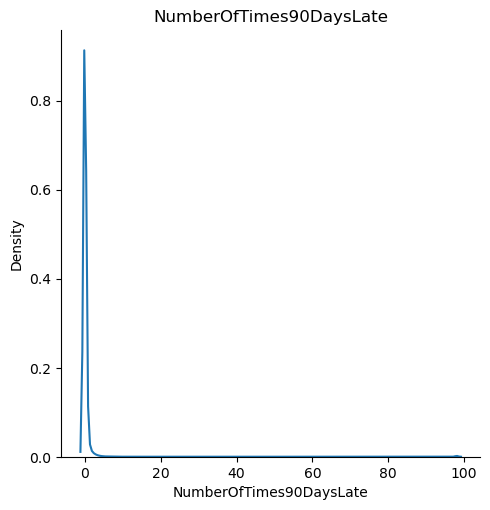

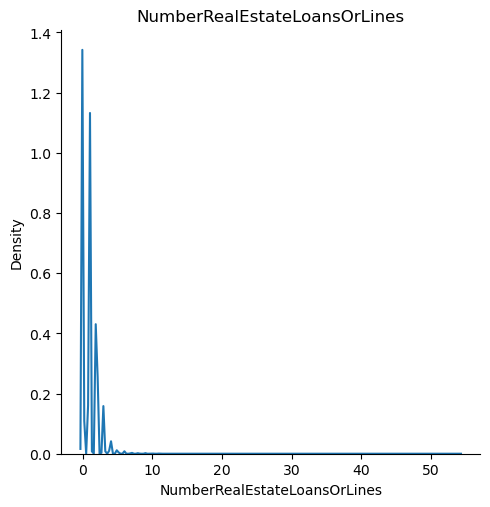

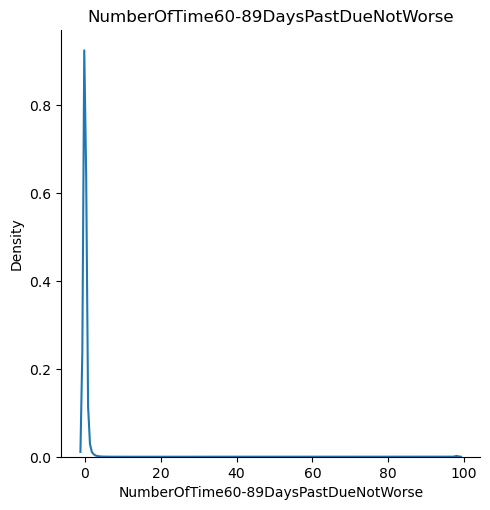

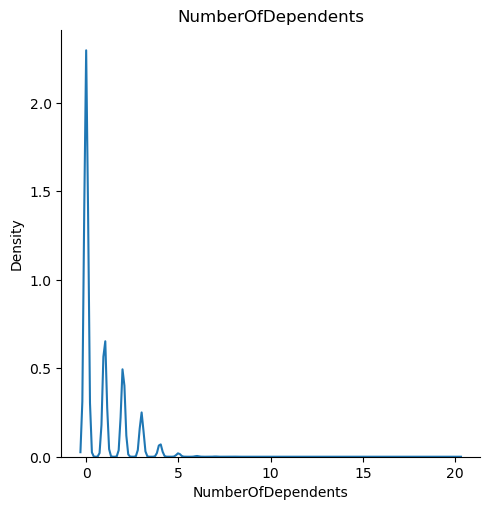

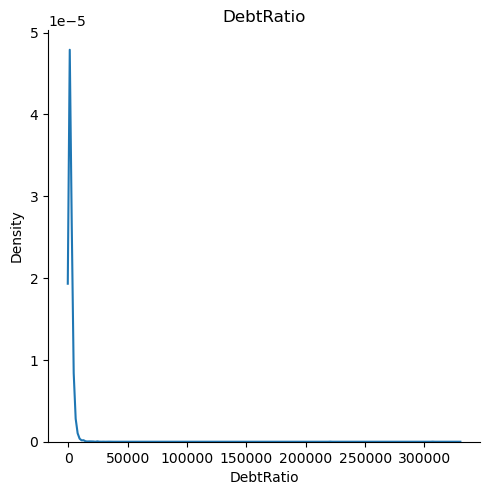

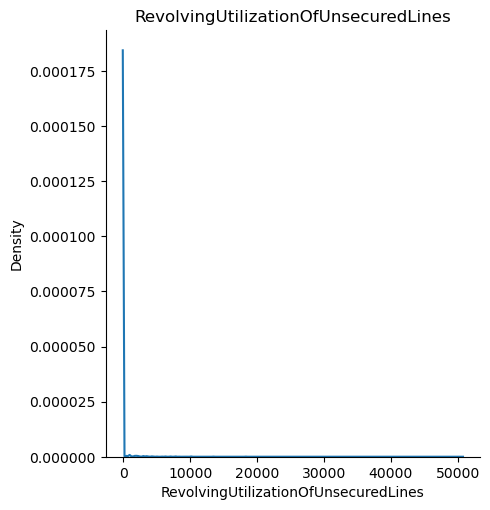

In [34]:
for col in hist_columns:
    plt.Figure(figsize= (8,3))
    sns.displot(data = df, x = col, kind = "kde")
    plt.title(col)
    plt.show()

In [35]:
df["RevolvingUtilizationOfUnsecuredLines"].describe(
    percentiles=[0.90, 0.95, 0.99]
)

count   150000.00
mean         6.05
std        249.76
min          0.00
50%          0.15
90%          0.98
95%          1.00
99%          1.09
max      50708.00
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

### Model Öncesi Yapılacaklar

- Defaulta düşülen gün sayılarında 93, 96, 98 gibi değerler NaN olarak değiştirilip, Median ile doldurulacak. Sonrasında bu kolonlarda yer alan bu 3 değer için is_special kolonu açılacak.
- Veri imbalanced olduğundan stratify = y kullanılacak train-test ayrımında.
- Monthly Income için log dönüşümü yapılacak, outlier değerlerin modeli etkilemesini engellemek amacıyla.
- Logistic Regression için standard scaler kullanılabilir, logistic regression mesafe tabanlı bir model olduğundan verilerin arasında devasa farklılıklar olduğunda model overfit edebilir.

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
df["NumberOfTime30-59DaysPastDueNotWorse"].value_counts().sort_index()

NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

In [38]:
dfm = df.copy()

In [39]:
dfm["is_special_30_59"] = (
    (
        (dfm["NumberOfTime30-59DaysPastDueNotWorse"] == 96) |
        (dfm["NumberOfTime30-59DaysPastDueNotWorse"] == 98)
    )
    .astype(int)
)

In [40]:
dfm["is_special_60_89"] = (
    (
        (dfm["NumberOfTime60-89DaysPastDueNotWorse"] == 96) |
        (dfm["NumberOfTime60-89DaysPastDueNotWorse"] == 98)
    )
    .astype(int)
)

In [41]:
dfm["is_special_90"] = (
    (
        (dfm["NumberOfTimes90DaysLate"] == 96) |
        (dfm["NumberOfTimes90DaysLate"] == 98)
    )
    .astype(int)
)

In [42]:
dfm.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,is_special_30_59,is_special_60_89,is_special_90
0,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00,0,0,0
1,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00,0,0,0
2,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00,0,0,0
3,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00,0,0,0
4,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00,0,0,0


In [43]:
dfm["NumberOfTimes90DaysLate"] = dfm["NumberOfTimes90DaysLate"].replace([98,96],np.nan)
dfm["NumberOfTime60-89DaysPastDueNotWorse"] = dfm["NumberOfTime60-89DaysPastDueNotWorse"].replace([98,96],np.nan)
dfm["NumberOfTime30-59DaysPastDueNotWorse"] = dfm["NumberOfTime30-59DaysPastDueNotWorse"].replace([98,96],np.nan)


In [44]:
dfm.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'is_special_30_59', 'is_special_60_89',
       'is_special_90'],
      dtype='object')

In [45]:
X = dfm.drop(columns=["SeriousDlqin2yrs"])
y = dfm["SeriousDlqin2yrs"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.2, stratify= y
)

In [47]:
from sklearn.impute import SimpleImputer

In [48]:
impute = SimpleImputer(strategy= "median")

In [49]:
X_train_impute = impute.fit_transform(X_train)
X_test_impute = impute.transform(X_test)

In [50]:
X_train_impute.shape

(120000, 13)

In [51]:
X_train = pd.DataFrame(
    data = X_train_impute,
    columns = X_train.columns,
    index = X_train.index
)

X_test = pd.DataFrame(
    data = X_test_impute,
    columns = X_test.columns,
    index = X_test.index
)

In [52]:

dfm.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,is_special_30_59,is_special_60_89,is_special_90
count,150000.00,150000.00,150000.00,149731.00,150000.00,120269.00,150000.00,149731.00,150000.00,149731.00,146076.00,150000.00,150000.00,150000.00
mean,0.07,6.05,52.30,0.25,353.01,6670.22,8.45,0.09,1.02,0.06,0.76,0.00,0.00,0.00
std,0.25,249.76,14.77,0.70,2037.82,14384.67,5.15,0.49,1.13,0.33,1.12,0.04,0.04,0.04
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00,0.00,0.00,0.00
max,1.00,50708.00,109.00,13.00,329664.00,3008750.00,58.00,17.00,54.00,11.00,20.00,1.00,1.00,1.00


In [53]:
from sklearn.preprocessing import RobustScaler, StandardScaler

In [54]:
scaler = StandardScaler()

In [55]:
dfm["MonthlyIncome"] = np.log1p(dfm["MonthlyIncome"])
dfm["DebtRatio"] = np.log1p(dfm["DebtRatio"])
dfm["RevolvingUtilizationOfUnsecuredLines"] = np.log1p(dfm["RevolvingUtilizationOfUnsecuredLines"])

In [56]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
logistic = LogisticRegression()

In [59]:
logistic.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [60]:
y_pred = logistic.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score

In [62]:
accuracy_score_base_model = accuracy_score(y_test, y_pred)
classification_report_base_model = classification_report(y_test, y_pred, output_dict= True)
confusion_matrix_base_model = confusion_matrix(y_test, y_pred)

In [63]:
classification_report_base_model

{'0': {'precision': 0.9425895765472313,
  'recall': 0.992320057153063,
  'f1-score': 0.9668157377277394,
  'support': 27995.0},
 '1': {'precision': 0.5928030303030303,
  'recall': 0.15610972568578554,
  'f1-score': 0.24713778128701144,
  'support': 2005.0},
 'accuracy': 0.9364333333333333,
 'macro avg': {'precision': 0.7676963034251307,
  'recall': 0.5742148914194243,
  'f1-score': 0.6069767595073754,
  'support': 30000.0},
 'weighted avg': {'precision': 0.9192121757065772,
  'recall': 0.9364333333333333,
  'f1-score': 0.9187172609722841,
  'support': 30000.0}}

In [64]:
y_pred_proba = logistic.predict_proba(X_test)[:, 1]

In [65]:
roc_auc_score_base_model = roc_auc_score(y_test, y_pred_proba)
pr_auc_base_model = average_precision_score(y_test, y_pred_proba)

In [66]:
dfm["SeriousDlqin2yrs"].value_counts(normalize= True)

SeriousDlqin2yrs
0   0.93
1   0.07
Name: proportion, dtype: float64

In [67]:
logistic_balanced = LogisticRegression(class_weight= "balanced")

In [68]:
logistic_balanced.fit(X_train, y_train)
y_pred_balanced = logistic_balanced.predict(X_test)

In [69]:
accuracy_score_balanced_model = accuracy_score(y_test, y_pred_balanced)
classification_report_balanced_model = classification_report(y_test, y_pred_balanced, output_dict= True)
confusion_matrix_balanced_model = confusion_matrix(y_test, y_pred_balanced)

In [70]:
y_pred_proba_balanced = logistic_balanced.predict_proba(X_test)[0:,1]

In [71]:
roc_auc_score_balanced_model = roc_auc_score(y_test, y_pred_proba_balanced)
pr_auc_balanced_model =  average_precision_score(y_test, y_pred_proba_balanced)

In [72]:
threshold = [0.10, 0.20, 0.30, 0.40, 0.50]
for th in threshold:
    y_pred_thr = (y_pred_proba_balanced >= th)
    print(th)
    print("-"*50)
    print("score: ", accuracy_score(y_test, y_pred_thr))
    print("report: ", classification_report(y_test, y_pred_thr))
    print("matrix: ", confusion_matrix(y_test, y_pred_thr))

0.1
--------------------------------------------------
score:  0.06953333333333334
report:                precision    recall  f1-score   support

           0       0.98      0.00      0.01     27995
           1       0.07      1.00      0.13      2005

    accuracy                           0.07     30000
   macro avg       0.52      0.50      0.07     30000
weighted avg       0.92      0.07      0.01     30000

matrix:  [[   83 27912]
 [    2  2003]]
0.2
--------------------------------------------------
score:  0.1973
report:                precision    recall  f1-score   support

           0       0.99      0.14      0.25     27995
           1       0.08      0.99      0.14      2005

    accuracy                           0.20     30000
   macro avg       0.53      0.56      0.19     30000
weighted avg       0.93      0.20      0.24     30000

matrix:  [[ 3943 24052]
 [   29  1976]]
0.3
--------------------------------------------------
score:  0.47213333333333335
report:     

In [73]:
results_model = []

In [74]:
results_model = []

results_model.append (
{
    "Model": "Logistic Base Model",
    "Accuracy Score": accuracy_score_base_model,
    "TN": confusion_matrix_base_model[0][0],
    "FP": confusion_matrix_base_model[0][1],
    "FN": confusion_matrix_base_model[1][0],
    "TP": confusion_matrix_base_model[1][1],
    "Precision_0": classification_report_base_model["0"]["precision"],
    "Recall_0": classification_report_base_model["0"]["recall"],
    "F1_0": classification_report_base_model["0"]["f1-score"],
    "Precision_1": classification_report_base_model["1"]["precision"],
    "Recall_1": classification_report_base_model["1"]["recall"],
    "F1_1": classification_report_base_model["1"]["f1-score"],
    "ROC_AUC": roc_auc_score_base_model,
    "PR-AUC": pr_auc_base_model}
)
results_model.append({
    "Model": "Logistic Balanced Model",
    "Accuracy Score": accuracy_score_balanced_model,
    "TN": confusion_matrix_balanced_model[0][0],
    "FP": confusion_matrix_balanced_model[0][1],
    "FN": confusion_matrix_balanced_model[1][0],
    "TP": confusion_matrix_balanced_model[1][1],
   "Precision_0": classification_report_balanced_model["0"]["precision"],
    "Recall_0": classification_report_balanced_model["0"]["recall"],
    "F1_0": classification_report_balanced_model["0"]["f1-score"],
    "Precision_1": classification_report_balanced_model["1"]["precision"],
    "Recall_1": classification_report_balanced_model["1"]["recall"],
    "F1_1": classification_report_balanced_model["1"]["f1-score"],
    "ROC_AUC": roc_auc_score_balanced_model,
    "PR-AUC": pr_auc_balanced_model
})

model_results = pd.DataFrame(results_model)


In [75]:
model_results

,Model,Accuracy Score,TN,FP,FN,TP,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,ROC_AUC,PR-AUC
0,Logistic Base Model,0.94,27780,215,1692,313,0.94,0.99,0.97,0.59,0.16,0.25,0.82,0.36
1,Logistic Balanced Model,0.86,24598,3397,743,1262,0.97,0.88,0.92,0.27,0.63,0.38,0.83,0.36


In [76]:
from sklearn.model_selection import GridSearchCV

In [77]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
    }

In [78]:
grid = GridSearchCV(
    estimator=logistic_balanced,
    param_grid=param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=3
)

In [79]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 5/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.362 total time=   0.2s
[CV 4/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.349 total time=   0.2s
[CV 1/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.354 total time=   0.2s
[CV 3/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.344 total time=   0.2s
[CV 2/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.359 total time=   0.2s
[CV 3/5] END C=0.001, penalty=l2, solver=liblinear;, score=0.347 total time=   0.2s
[CV 1/5] END C=0.001, penalty=l2, solver=liblinear;, score=0.355 total time=   0.2s
[CV 4/5] END C=0.001, penalty=l2, solver=liblinear;, score=0.351 total time=   0.2s
[CV 5/5] END C=0.001, penalty=l2, solver=liblinear;, score=0.362 total time=   0.2s
[CV 2/5] END C=0.001, penalty=l2, solver=liblinear;, score=0.361 total time=   0.3s
[CV 1/5] END ..C=0.001, penalty=l1, solver=saga;, score=0.353 total time=   0.6s
[CV 5/5] END ..C=

,estimator,LogisticRegre...ht='balanced')
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [80]:
y_pred_grid = grid.predict(X_test)

In [81]:
y_pred_proba_grid = grid.predict_proba(X_test)[0:,1]

In [82]:
print("score: ", accuracy_score(y_test, y_pred_grid))
print("matrix: ", confusion_matrix(y_test, y_pred_grid))
print("classification: ", classification_report(y_test, y_pred_grid))
print("roc-auc_score:", roc_auc_score(y_test, y_pred_proba_grid))
print("pr_auc:", average_precision_score(y_test, y_pred_proba_grid))

score:  0.862
matrix:  [[24599  3396]
 [  744  1261]]
classification:                precision    recall  f1-score   support

           0       0.97      0.88      0.92     27995
           1       0.27      0.63      0.38      2005

    accuracy                           0.86     30000
   macro avg       0.62      0.75      0.65     30000
weighted avg       0.92      0.86      0.89     30000

roc-auc_score: 0.8254819728674384
pr_auc: 0.36306167577464726


In [83]:
accuracy_score_grid_model = accuracy_score(y_test, y_pred_grid)
confusion_matrix_grid_model = confusion_matrix(y_test, y_pred_grid)
classification_report_grid_model = classification_report(y_test, y_pred_grid, output_dict= True)
roc_auc_score_grid_model = roc_auc_score(y_test, y_pred_proba_grid)
pr_auc_grid_model = average_precision_score(y_test, y_pred_proba_grid)

In [164]:
results_model = []

results_model.append (
{
    "Model": "Logistic Base Model",
    "Accuracy Score": accuracy_score_base_model,
    "TN": confusion_matrix_base_model[0][0],
    "FP": confusion_matrix_base_model[0][1],
    "FN": confusion_matrix_base_model[1][0],
    "TP": confusion_matrix_base_model[1][1],
    "Precision_0": classification_report_base_model["0"]["precision"],
    "Recall_0": classification_report_base_model["0"]["recall"],
    "F1_0": classification_report_base_model["0"]["f1-score"],
    "Precision_1": classification_report_base_model["1"]["precision"],
    "Recall_1": classification_report_base_model["1"]["recall"],
    "F1_1": classification_report_base_model["1"]["f1-score"],
    "ROC_AUC": roc_auc_score_base_model,
    "PR-AUC": pr_auc_base_model}
)
results_model.append({
    "Model": "Logistic Balanced Model",
    "Accuracy Score": accuracy_score_balanced_model,
    "TN": confusion_matrix_balanced_model[0][0],
    "FP": confusion_matrix_balanced_model[0][1],
    "FN": confusion_matrix_balanced_model[1][0],
    "TP": confusion_matrix_balanced_model[1][1],
   "Precision_0": classification_report_balanced_model["0"]["precision"],
    "Recall_0": classification_report_balanced_model["0"]["recall"],
    "F1_0": classification_report_balanced_model["0"]["f1-score"],
    "Precision_1": classification_report_balanced_model["1"]["precision"],
    "Recall_1": classification_report_balanced_model["1"]["recall"],
    "F1_1": classification_report_balanced_model["1"]["f1-score"],
    "ROC_AUC": roc_auc_score_balanced_model,
    "PR-AUC": pr_auc_balanced_model
})
results_model.append({
    "Model": "Logistic Grid Model",
    "Accuracy Score": accuracy_score_grid_model,
    "TN": confusion_matrix_grid_model[0][0],
    "FP": confusion_matrix_grid_model[0][1],
    "FN": confusion_matrix_grid_model[1][0],
    "TP": confusion_matrix_grid_model[1][1],
   "Precision_0": classification_report_grid_model["0"]["precision"],
    "Recall_0": classification_report_grid_model["0"]["recall"],
    "F1_0": classification_report_grid_model["0"]["f1-score"],
    "Precision_1": classification_report_grid_model["1"]["precision"],
    "Recall_1": classification_report_grid_model["1"]["recall"],
    "F1_1": classification_report_grid_model["1"]["f1-score"],
    "ROC_AUC": roc_auc_score_grid_model,
    "PR-AUC": roc_auc_score_grid_model
})
results_model.append({
    "Model": "KNN Model",
    "Accuracy Score": accuracy_score_knn_model,
    "TN": confusion_matrix_knn_model[0][0],
    "FP": confusion_matrix_knn_model[0][1],
    "FN": confusion_matrix_knn_model[1][0],
    "TP": confusion_matrix_knn_model[1][1],
   "Precision_0": classification_report_knn_model["0"]["precision"],
    "Recall_0": classification_report_knn_model["0"]["recall"],
    "F1_0": classification_report_knn_model["0"]["f1-score"],
    "Precision_1": classification_report_knn_model["1"]["precision"],
    "Recall_1": classification_report_knn_model["1"]["recall"],
    "F1_1": classification_report_knn_model["1"]["f1-score"],
    "ROC_AUC": roc_auc_score_knn_model,
    "PR-AUC": pr_auc_knn_model
})
results_model.append({
    "Model": "KNN Grid Model",
    "Accuracy Score": accuracy_score_knn_grid_model,
    "TN": confusion_matrix_knn_grid_model[0][0],
    "FP": confusion_matrix_knn_grid_model[0][1],
    "FN": confusion_matrix_knn_grid_model[1][0],
    "TP": confusion_matrix_knn_grid_model[1][1],
   "Precision_0": classification_report_knn_grid_model["0"]["precision"],
    "Recall_0": classification_report_knn_grid_model["0"]["recall"],
    "F1_0": classification_report_knn_grid_model["0"]["f1-score"],
    "Precision_1": classification_report_knn_grid_model["1"]["precision"],
    "Recall_1": classification_report_knn_grid_model["1"]["recall"],
    "F1_1": classification_report_knn_grid_model["1"]["f1-score"],
    "ROC_AUC": roc_auc_score_knn_grid_model,
    "PR-AUC": pr_auc_knn_grid_model
})
results_model.append({
    "Model": "Random Forest Base Classifier Model",
    "Accuracy Score": accuracy_score_rfc_model,
    "TN": confusion_matrix_rfc_model[0][0],
    "FP": confusion_matrix_rfc_model[0][1],
    "FN": confusion_matrix_rfc_model[1][0],
    "TP": confusion_matrix_rfc_model[1][1],
   "Precision_0": classification_report_rfc_model["0"]["precision"],
    "Recall_0": classification_report_rfc_model["0"]["recall"],
    "F1_0": classification_report_rfc_model["0"]["f1-score"],
    "Precision_1": classification_report_rfc_model["1"]["precision"],
    "Recall_1": classification_report_rfc_model["1"]["recall"],
    "F1_1": classification_report_rfc_model["1"]["f1-score"],
    "ROC_AUC": roc_auc_score_rfc_model,
    "PR-AUC": pr_auc_rfc_model
})

results_model.append({
    "Model": "Random Forest n_est Classifier Model",
    "Accuracy Score": accuracy_score_rfc_n_model,
    "TN": confusion_matrix_rfc_n_model[0][0],
    "FP": confusion_matrix_rfc_n_model[0][1],
    "FN": confusion_matrix_rfc_n_model[1][0],
    "TP": confusion_matrix_rfc_n_model[1][1],
   "Precision_0": classification_report_rfc_n_model["0"]["precision"],
    "Recall_0": classification_report_rfc_n_model["0"]["recall"],
    "F1_0": classification_report_rfc_n_model["0"]["f1-score"],
    "Precision_1": classification_report_rfc_n_model["1"]["precision"],
    "Recall_1": classification_report_rfc_n_model["1"]["recall"],
    "F1_1": classification_report_rfc_n_model["1"]["f1-score"],
    "ROC_AUC": roc_auc_score_rfc_n_model,
    "PR-AUC": pr_auc_rfc_n_model
})

results_model.append({
    "Model": "Random Forest Max_Depth Classifier Model",
    "Accuracy Score": accuracy_score_rfc_max_model,
    "TN": confusion_matrix_rfc_max_model[0][0],
    "FP": confusion_matrix_rfc_max_model[0][1],
    "FN": confusion_matrix_rfc_max_model[1][0],
    "TP": confusion_matrix_rfc_max_model[1][1],
   "Precision_0": classification_report_rfc_max_model["0"]["precision"],
    "Recall_0": classification_report_rfc_max_model["0"]["recall"],
    "F1_0": classification_report_rfc_max_model["0"]["f1-score"],
    "Precision_1": classification_report_rfc_max_model["1"]["precision"],
    "Recall_1": classification_report_rfc_max_model["1"]["recall"],
    "F1_1": classification_report_rfc_max_model["1"]["f1-score"],
    "ROC_AUC": roc_auc_score_rfc_max_model,
    "PR-AUC": pr_auc_rfc_max_model
})


model_results = pd.DataFrame(results_model)


In [85]:
model_results

,Model,Accuracy Score,TN,FP,FN,TP,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,ROC_AUC,PR-AUC
0,Logistic Base Model,0.94,27780,215,1692,313,0.94,0.99,0.97,0.59,0.16,0.25,0.82,0.36
1,Logistic Balanced Model,0.86,24598,3397,743,1262,0.97,0.88,0.92,0.27,0.63,0.38,0.83,0.36


### Logistic Modeller Proje Özeti

- Target değişkene göre kolonların dağılımı incelenerek veriden anlam çıkartılmaya çalışıldı.
- Eksik değerlerin rastgelelikten mi yoksa bilinçli mi olduğuna yönelik çıkarım yapılabilmesi için, eksik değer içeren kolonların diğer metriklerle ilişkileri incelendi.
- Default kolonu ile korelatif olan kolonlar ve dağılımları incelendi.
- Gecikme gün sayısı kolonlarında yer alan maks değerler outlier yaratıyordu. Bu değerlerin veriseti özelinde bir anlam ifade edebildiğini düşündüğümden is_special kolonları oluşturuldu. Böylece bu outlier değere sahip 3 kolon için is_special değerleri oluşturularak modelin bu kolonlardan da anlam çıkartmaya çalışması sağlandı. 
- Eksik değer içeren kolonlar için median imputation yapıldı. Kolonlarda yer alan outlier değerlerin fazla olması sebebiyle median tercih edildi.
- Log dönüşümü yapılarak verideki çarpıklığın azaltılması hedeflendi, büyük değerler sıkıştırılarak outlier hafifletilmeye çalışıldı.
- Scaling kullanarak verinin yeniden ölçeklendirilmesi sağlandı ve değişkenler ortak bir alanda toplandı. StandardScaler seçilmesinin sebebi kolonlar arasında meanlar anlamlı olduğundan dolayı. 
- Class Weight kullanarak imbalanced datasete karşı önlem almayı denedim. TP değerlerde ciddi bir artış olmasına rağmen precisionda ciddi bir düşüş yaşadık. ROC-AUC ve PR-AUC metriklerinde ciddi bir gelişme yaşanmadı.
- 0.40, 0.35 thresholdları kullanarak recall arttırmaya yönelik denemeler yaptık. 
- GridSearch scoring = PR-AUC vererek bir grid denedik. C regülarizasyonu, penalty ve solver ile çeşitli parametreler denedik. Ancak balanced model ile çok fazla bir değişim olmadı. Bunun sebebi threshold olarak %50 kullanılması. 



### KNN

In [86]:
from sklearn.neighbors import KNeighborsClassifier

In [88]:
knn = KNeighborsClassifier(
    n_neighbors = 5,
    weights = "uniform",
    metric = "minkowski",
    p= 2
)

In [91]:
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_pred_proba_knn = knn.predict_proba(X_test)[0:,1]

In [94]:
accuracy_score_knn_model = accuracy_score(y_test, y_pred_knn)
confusion_matrix_knn_model = confusion_matrix(y_test, y_pred_knn)
classification_report_knn_model = classification_report(y_test, y_pred_knn, output_dict= True)
roc_auc_score_knn_model = roc_auc_score(y_test, y_pred_proba_knn)
pr_auc_knn_model = average_precision_score(y_test, y_pred_proba_knn)

In [ ]:
model_results


,Model,Accuracy Score,TN,FP,FN,TP,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,ROC_AUC,PR-AUC
0,Logistic Base Model,0.94,27780,215,1692,313,0.94,0.99,0.97,0.59,0.16,0.25,0.82,0.36
1,Logistic Balanced Model,0.86,24598,3397,743,1262,0.97,0.88,0.92,0.27,0.63,0.38,0.83,0.36
2,Logistic Grid Model,0.86,24599,3396,744,1261,0.97,0.88,0.92,0.27,0.63,0.38,0.83,0.83
3,KNN Model,0.93,27580,415,1606,399,0.94,0.99,0.96,0.49,0.20,0.28,0.73,0.23


In [101]:
param_grid = [{
    "n_neighbors": [3,5,7,9,11,15,21],
    "weights": ["distance"],
    "metric": ["euclidean", "manhattan"]

}]

In [102]:
knn_g = KNeighborsClassifier()

In [103]:
knn_grid = GridSearchCV(
    estimator= knn_g,
    param_grid= param_grid,
    n_jobs= -1,
    verbose= 3
)

In [104]:
knn_grid.fit(X_train, y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


[CV 3/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=0.917 total time=   9.7s
[CV 5/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=0.918 total time=   9.9s
[CV 4/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=0.918 total time=  10.1s
[CV 2/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=0.917 total time=  10.4s
[CV 3/5] END metric=euclidean, n_neighbors=5, weights=distance;, score=0.924 total time=  10.4s
[CV 1/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=0.917 total time=  10.6s
[CV 5/5] END metric=euclidean, n_neighbors=5, weights=distance;, score=0.926 total time=  10.7s
[CV 4/5] END metric=euclidean, n_neighbors=5, weights=distance;, score=0.926 total time=  11.4s
[CV 1/5] END metric=euclidean, n_neighbors=5, weights=distance;, score=0.925 total time=  11.7s
[CV 2/5] END metric=euclidean, n_neighbors=5, weights=distance;, score=0.924 total time=  11.7s
[CV 3/5] END metric=euclidean, n_neighbo

,estimator,KNeighborsClassifier()
,param_grid,"[{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['distance']}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,21


In [105]:
y_pred_grid_knn = knn_grid.predict(X_test)
y_pred_grid_knn_proba = knn_grid.predict_proba(X_test)[0:,1]

In [106]:
accuracy_score_knn_grid_model = accuracy_score(y_test, y_pred_grid_knn)
confusion_matrix_knn_grid_model = confusion_matrix(y_test, y_pred_grid_knn)
classification_report_knn_grid_model = classification_report(y_test, y_pred_grid_knn, output_dict= True)
roc_auc_score_knn_grid_model = roc_auc_score(y_test, y_pred_grid_knn_proba)
pr_auc_knn_grid_model = average_precision_score(y_test, y_pred_grid_knn_proba)

In [109]:
model_results


,Model,Accuracy Score,TN,FP,FN,TP,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,ROC_AUC,PR-AUC
0,Logistic Base Model,0.94,27780,215,1692,313,0.94,0.99,0.97,0.59,0.16,0.25,0.82,0.36
1,Logistic Balanced Model,0.86,24598,3397,743,1262,0.97,0.88,0.92,0.27,0.63,0.38,0.83,0.36
2,Logistic Grid Model,0.86,24599,3396,744,1261,0.97,0.88,0.92,0.27,0.63,0.38,0.83,0.83
3,KNN Model,0.93,27580,415,1606,399,0.94,0.99,0.96,0.49,0.20,0.28,0.73,0.23
4,KNN Grid Model,0.93,27650,345,1641,364,0.94,0.99,0.97,0.51,0.18,0.27,0.79,0.30


In [110]:
from sklearn.ensemble import RandomForestClassifier

In [111]:
rfc = RandomForestClassifier()

In [112]:
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [113]:
y_pred_rfc = rfc.predict(X_test)

In [117]:
y_pred_proba_rf = rfc.predict_proba(X_test)[0:,1]

In [119]:
accuracy_score_rfc_model = accuracy_score(y_test, y_pred_rfc)
confusion_matrix_rfc_model = confusion_matrix(y_test, y_pred_rfc)
classification_report_rfc_model = classification_report(y_test, y_pred_rfc, output_dict= True)
roc_auc_score_rfc_model = roc_auc_score(y_test, y_pred_proba_rf)
pr_auc_rfc_model = average_precision_score(y_test, y_pred_proba_rf)


In [125]:
model_results[model_results["Model"] == 'Random Forest Base Classifier Model']

,Model,Accuracy Score,TN,FP,FN,TP,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,ROC_AUC,PR-AUC
5,Random Forest Base Classifier Model,0.94,27725,270,1646,359,0.94,0.99,0.97,0.57,0.18,0.27,0.84,0.36


In [138]:
param_grid_rf = {
    "n_estimators": [10,50,100,500]
}

In [141]:
grid_rf_n = GridSearchCV(param_grid= param_grid_rf, estimator= rfc, verbose= 2, n_jobs= -1)

In [142]:
grid_rf_n.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


[CV] END ....................................n_estimators=10; total time=   1.3s
[CV] END ....................................n_estimators=10; total time=   1.3s
[CV] END ....................................n_estimators=10; total time=   1.3s
[CV] END ....................................n_estimators=10; total time=   1.3s
[CV] END ....................................n_estimators=10; total time=   1.3s
[CV] END ....................................n_estimators=50; total time=   5.6s
[CV] END ....................................n_estimators=50; total time=   5.7s
[CV] END ....................................n_estimators=50; total time=   5.6s
[CV] END ....................................n_estimators=50; total time=   5.5s
[CV] END ....................................n_estimators=50; total time=   5.6s
[CV] END ...................................n_estimators=100; total time=  11.2s
[CV] END ...................................n_estimators=100; total time=  11.2s
[CV] END ...................

,estimator,RandomForestClassifier()
,param_grid,"{'n_estimators': [10, 50, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [146]:
y_pred_grid_rf_n = grid_rf_n.predict(X_test)
y_pred_grid_rf_n_proba = grid_rf_n.predict_proba(X_test)[0:,1]

In [147]:
accuracy_score_rfc_n_model = accuracy_score(y_test, y_pred_grid_rf_n)
confusion_matrix_rfc_n_model = confusion_matrix(y_test, y_pred_grid_rf_n)
classification_report_rfc_n_model = classification_report(y_test, y_pred_grid_rf_n, output_dict= True)
roc_auc_score_rfc_n_model = roc_auc_score(y_test, y_pred_grid_rf_n_proba)
pr_auc_rfc_n_model = average_precision_score(y_test, y_pred_grid_rf_n_proba)


In [155]:
model_results

,Model,Accuracy Score,TN,FP,FN,TP,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,ROC_AUC,PR-AUC
0,Logistic Base Model,0.94,27780,215,1692,313,0.94,0.99,0.97,0.59,0.16,0.25,0.82,0.36
1,Logistic Balanced Model,0.86,24598,3397,743,1262,0.97,0.88,0.92,0.27,0.63,0.38,0.83,0.36
2,Logistic Grid Model,0.86,24599,3396,744,1261,0.97,0.88,0.92,0.27,0.63,0.38,0.83,0.83
3,KNN Model,0.93,27580,415,1606,399,0.94,0.99,0.96,0.49,0.20,0.28,0.73,0.23
4,KNN Grid Model,0.93,27650,345,1641,364,0.94,0.99,0.97,0.51,0.18,0.27,0.79,0.30
5,Random Forest Base Classifier Model,0.94,27725,270,1646,359,0.94,0.99,0.97,0.57,0.18,0.27,0.84,0.36
6,Random Forest n_est Classifier Model,0.94,27729,266,1640,365,0.94,0.99,0.97,0.58,0.18,0.28,0.85,0.37


In [ ]:
rfc_max_depth = RandomForestClassifier(n_estimators= 500, max_depth= 13)
rfc_max_depth.fit(X_train, y_train)
y_pred_rfc_max = rfc_max_depth.predict(X_test)
y_pred_rfc_max_proba = rfc_max_depth.predict_proba(X_test)[0:,1]

In [163]:
accuracy_score_rfc_max_model = accuracy_score(y_test, y_pred_rfc_max)
confusion_matrix_rfc_max_model = confusion_matrix(y_test, y_pred_rfc_max)
classification_report_rfc_max_model = classification_report(y_test, y_pred_rfc_max, output_dict= True)
roc_auc_score_rfc_max_model = roc_auc_score(y_test, y_pred_rfc_max_proba)
pr_auc_rfc_max_model = average_precision_score(y_test, y_pred_rfc_max_proba)


In [166]:
param_grid = {
    "n_estimators": [10,50,100,500],
    "max_depth": [5,6,7,10,13,16,18],
    "min_samples_leaf": [1,2,5,10,20]
}

In [169]:
rf_grid_all = RandomForestClassifier()

In [171]:
grid_rf_all = GridSearchCV(param_grid= param_grid, 
                           estimator= rf_grid_all, 
                           n_jobs= -1, verbose= 2)

In [172]:
grid_rf_all.fit(X_train, y_train)

Fitting 5 folds for each of 140 candidates, totalling 700 fits
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=10; total time=   0.4s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=10; total time=   0.4s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=10; total time=   0.4s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=10; total time=   0.5s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=10; total time=   0.5s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   1.9s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   1.9s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   1.9s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   2.0s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   2.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   3.7s
[CV] END ..max_depth=5, min_samples_leaf=1, n_

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [5, 6, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [10, 50, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500
